# Proyecto Final DataXpeience

##Airbnb Bogotá

## De datos a decisiones: el mercado de Airbnb en Bogotá

**Integrantes:** Eimy Nicolle Rubio · Laura Torres · Juan Esteban Melo · Juan Serrano  
**Curso:** Data Experience  G4
**Ciudad analizada:** Bogotá, Colombia


### Resumen

El proyecto analiza un conjunto de datos de alojamientos de Airbnb en Bogotá con el propósito de estudiar la relación entre ocupación, precio, ubicación, características del alojamiento y calidad percibida. El flujo seguido comprende la obtención de los datos, su limpieza y transformación, el análisis exploratorio y el análisis estadístico mediante agrupaciones y correlaciones.

El conjunto inicial utilizado por el grupo contiene **19.187 registros y 90 variables**. Después de la limpieza y selección de variables, el conjunto de trabajo queda en **18.949 registros y 34 variables**. Entre los principales hallazgos se encuentra que el precio por noche, por sí solo, presenta una relación lineal muy débil con la ocupación, mientras que el tipo de alojamiento y la ubicación muestran diferencias más visibles en los promedios de ocupación.




# 1. Planteamiento del problema

Airbnb reúne información sobre alojamientos, anfitriones, precios, ubicación, características de las propiedades y calificaciones. Esta información permite estudiar qué características están asociadas con un mejor desempeño de los listados en Bogotá.

El problema de análisis se centra en entender **qué factores están relacionados con la ocupación y con la calificación general**. En lugar de observar solamente una variable, se consideran conjuntamente aspectos económicos, geográficos, físicos y de experiencia del huésped.

## Pregunta principal

> **¿Qué características de un listado de propiedades de Airbnb en Bogotá predicen mejor su calificación general y su nivel de ocupación, según propiedades activas en los últimos 12 meses?**

## Preguntas de apoyo

1. ¿Cuál es el rango de precios que presenta mayores niveles de ocupación?
2. ¿Qué zonas de Bogotá concentran los alojamientos con mayor ocupación y mejores calificaciones?
3. ¿Qué características de la propiedad —habitaciones, camas, baños, tipo de propiedad y servicios— están relacionadas con una mayor ocupación?
4. ¿Qué factores explican mejor una calificación general?

## Objetivo general

Analizar las características de las propiedades de Airbnb activas en Bogotá durante los últimos 12 meses para identificar los factores relacionados con su nivel de ocupación y calificación general, considerando variables como precio, ubicación, características del alojamiento, servicios y calidad percibida.

## Objetivos específicos

- Comprender la estructura y calidad del conjunto de datos.
- Limpiar y preparar las variables necesarias para el análisis.
- Describir el comportamiento de precio, ocupación y calificaciones.
- Comparar la ocupación según tipo de alojamiento, ubicación y capacidad.
- Explorar la relación entre amenidades y calificación.
- Analizar la relación entre las subcalificaciones y el rating general.
- Comunicar los hallazgos mediante visualizaciones claras.


# 2. Fuente y obtención de los datos

La fuente principal del proyecto es **Inside Airbnb**, específicamente su sección pública **Get the Data**. La página permite acceder a datos de listados de distintas ciudades. Para este proyecto se utilizó el archivo correspondiente a Bogotá que fue descargado y cargado en Google Drive.

**Fuente principal:** [Inside Airbnb — Get the Data](https://insideairbnb.com/es/get-the-data/?hl=es-AR)

Inside Airbnb explica que sus datos se construyen a partir de información pública disponible sobre los listados y que los datos son procesados, limpiados, analizados y agregados. También advierte que la información representa una fotografía del mercado en un momento determinado y que la ubicación de los listados está anonimizada. Estas consideraciones son importantes para interpretar los resultados y no tratarlos como un censo permanente del mercado. [Inside Airbnb, Data Assumptions](https://insideairbnb.com/data-assumptions/)

## Justificación de la fuente

Se eligió esta fuente porque las variables disponibles están directamente relacionadas con las preguntas del proyecto: precio, disponibilidad, ocupación estimada, reseñas, calificaciones, ubicación, tipo de alojamiento, características físicas y atributos del anfitrión.

## Consideración sobre la ocupación

La variable `estimated_occupancy_l365d` debe interpretarse como una **estimación** y no como un conteo directo de reservas. Inside Airbnb explica la metodología utilizada para estimar ocupación a partir de reseñas, duración de estancia y disponibilidad. Por esta razón, en este informe se habla de *ocupación estimada* cuando se interpreta esta variable.


# 3. Comprensión del conjunto de datos y variables

El conjunto original contiene información de listados, anfitriones, precios, ubicación, características del alojamiento, disponibilidad y reseñas. Para facilitar el análisis, las variables seleccionadas se pueden organizar en los siguientes grupos:

| Grupo | Variables principales | Uso en el análisis |
|---|---|---|
| Ocupación | `estimated_occupancy_l365d` | Resultado principal de demanda |
| Calidad | `review_scores_rating` | Resultado de calidad percibida |
| Precio | `price` | Factor económico |
| Ubicación | `neighbourhood_cleansed`, `latitude`, `longitude` | Comparación geográfica |
| Alojamiento | `property_type`, `room_type` | Tipo de oferta |
| Capacidad | `accommodates`, `bedrooms`, `beds`, `bathrooms` | Características físicas |
| Servicios | `num_amenities` | Cantidad de amenidades |
| Reseñas | `number_of_reviews_ltm`, `reviews_per_month` | Actividad y experiencia |
| Ingresos | `estimated_revenue_l365d` | Resultado económico estimado |
| Host | `host_is_superhost`, `host_has_profile_pic`, `host_identity_verified` | Características del anfitrión |
| Calidad detallada | `review_scores_accuracy`, `review_scores_cleanliness`, `review_scores_checkin`, `review_scores_communication`, `review_scores_location`, `review_scores_value` | Componentes del rating |

La selección final de 34 variables se realiza  mediante la lista `columnas_utiles`.


# LIMPIEZA DE DATOS

## 4. Limpieza y preparación de los datos

La preparación se realiza sobre una copia del dataset original llamada `df_limpio`. Esta decisión permite conservar `df` como referencia del conjunto inicial y trabajar las transformaciones sobre una copia.

La limpieza sigue varias etapas:

1. Eliminación de columnas que no son necesarias para las preguntas del proyecto.
2. Conversión de `price` desde texto a valores numéricos.
3. Identificación y exclusión de valores de precio superiores a $4.000.000 por noche, considerados extremos para el contexto del análisis.
4. Corrección de problemas de codificación de caracteres y normalización de textos.
5. Tratamiento de valores faltantes en habitaciones, camas, baños, precio, reseñas e ingresos estimados.
6. Verificación de identificadores repetidos.
7. Transformación de `amenities` en una variable numérica llamada `num_amenities`.
8. Conversión de variables booleanas desde `t/f` a `True/False`.
9. Selección de las 34 variables utilizadas posteriormente en el análisis.

La limpieza es una parte central del proyecto porque las visualizaciones y las estadísticas posteriores dependen de que los tipos de datos, categorías y valores extremos estén tratados de forma consistente.


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
ruta = "/content/drive/MyDrive/DataXperience/dataset_airbnbbogota.csv"
df = pd.read_csv(ruta, encoding='latin-1')

df_limpio = df.copy() #Copia del dataset para no trabajar sobre el original

df_limpio.info()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19187 entries, 0 to 19186
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            19187 non-null  int64  
 1   listing_url                                   19187 non-null  object 
 2   scrape_id                                     19187 non-null  float64
 3   last_scraped                                  19187 non-null  object 
 4   source                                        19187 non-null  object 
 5   name                                          19187 non-null  object 
 6   description                                   18664 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture

In [ ]:
#Se eliminan las columnas vacias.

columnas_a_eliminar = [
    'neighborhood_overview','host_since','host_response_time','host_response_rate',
    'host_acceptance_rate','host_thumbnail_url','host_neighbourhood',
    'host_total_listings_count','host_verifications','neighbourhood',
    'neighbourhood_group_cleansed','calendar_updated','instant_bookable','listing_url','scrape_id','source','picture_url',
    'host_url','host_profile_id','host_profile_url','host_picture_url',
    'calendar_last_scraped','last_scraped','description','host_about',
    'price_quote_checkin_date','price_quote_checkout_date','price_quote_raw',
    'price_quote_total_price','license'
]

df_limpio = df_limpio.drop(columns=columnas_a_eliminar)
print(df_limpio.shape)



(19187, 60)


In [ ]:
#Se corrije la columna de precio (tipo de dato)

df_limpio['price'] = pd.to_numeric(
    df_limpio['price']
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False),
    errors='coerce'
)


print(df_limpio['price'].dtype)

# Casos Error (más de 4 millones/noche es poco realista para Bogotá)

print((df_limpio['price'] > 4000000).sum(), 'listados con precio > 4 millones')

# Eliminar esos casos del dataset limpio
df_limpio = df_limpio[df_limpio['price'] < 4000000]
print(df_limpio.shape)

float64
42 listados con precio > 4 millones
(18949, 60)


In [ ]:
# Revisar valores únicos para detectar inconsistencias (mayúsculas, tildes, espacios)
for col in ['neighbourhood_cleansed', 'property_type', 'room_type']:
    print(f"Valores únicos en {col}:")
    print(df_limpio[col].unique())
    print("\n")

# Corregir problemas de encoding (ej. "NariÃ±o" -> "Nariño")
def arreglar_encoding(texto):
    if isinstance(texto, str):
        try:
            return texto.encode('latin1').decode('utf-8')
        except (UnicodeDecodeError, UnicodeEncodeError):
            return texto
    return texto

for col in ['neighbourhood_cleansed', 'property_type', 'room_type']:
    df_limpio[col] = df_limpio[col].apply(arreglar_encoding)

# Corregir tambien los nombres de los alojamientos
df_limpio['name'] = df_limpio['name'].apply(arreglar_encoding)

# Normalizar texto: quitar espacios extra y homogeneizar mayúsculas/minúsculas
for col in ['neighbourhood_cleansed', 'property_type', 'room_type']:
    df_limpio[col] = df_limpio[col].str.strip().str.title()


print(df_limpio['neighbourhood_cleansed'].unique())
print(df_limpio['property_type'].unique())
print(df_limpio['room_type'].unique())

Valores únicos en neighbourhood_cleansed:
['Chapinero' 'Candelaria' 'Usaquen' 'Teusaquillo' 'Engativa' 'Suba'
 'Santa Fe' 'Barrios Unidos' 'Fontibon' 'Kennedy' 'Puente Aranda'
 'Los Martires' 'Rafael Uribe Uribe' 'Bosa' 'San Cristobal'
 'Antonio NariÃ±o' 'Usme' 'Sumapaz' 'Ciudad Bolivar' 'Tunjuelito']


Valores únicos en property_type:
['Entire serviced apartment' 'Entire loft' 'Entire rental unit'
 'Private room in home' 'Private room in rental unit'
 'Private room in loft' 'Private room in condo' 'Entire home'
 'Entire bed and breakfast' 'Entire condo' 'Room in boutique hotel'
 'Room in serviced apartment' 'Entire place'
 'Private room in vacation home' 'Private room in serviced apartment'
 'Entire guesthouse' 'Room in hotel' 'Private room in guest suite'
 'Private room in guesthouse' 'Private room in bed and breakfast'
 'Private room in townhouse' 'Private room' 'Entire townhouse'
 'Entire cottage' 'Private room in villa' 'Entire vacation home'
 'Tiny home' 'Entire guest suite' 'Cas

In [ ]:
# bedrooms, beds, bathrooms: nulos probablemente significan "no especificado" o "0"
df_limpio['bedrooms'] = df_limpio['bedrooms'].fillna(0)
df_limpio['beds'] = df_limpio['beds'].fillna(0)
df_limpio['bathrooms'] = df_limpio['bathrooms'].fillna(0)
df_limpio['price'] = df_limpio['price'].fillna(df_limpio['price'].median())
df_limpio['reviews_per_month'] = df_limpio['reviews_per_month'].fillna(0)
df_limpio['estimated_revenue_l365d'] = df_limpio['estimated_revenue_l365d'].fillna(0)


In [ ]:
#verificacion de ID repetidos
print(df.duplicated(subset='id').sum())

0


In [ ]:
#convertir Amenites en un dato qmas util
import ast


if 'amenities' not in df_limpio.columns:
    df_limpio = df_limpio.merge(df[['id', 'amenities']], on='id', how='left')

# Convertir el texto tipo lista en una lista real de Python
df_limpio['amenities_list'] = df_limpio['amenities'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

df_limpio['num_amenities'] = df_limpio['amenities_list'].apply(len)

df_limpio = df_limpio.drop(columns=['amenities', 'amenities_list'])

print(df_limpio['num_amenities'].describe())

count    18949.000000
mean        26.427938
std         14.524910
min          0.000000
25%         14.000000
50%         26.000000
75%         36.000000
max         90.000000
Name: num_amenities, dtype: float64


In [ ]:

columnas_booleanas = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability']

for col in columnas_booleanas:
    df_limpio[col] = df_limpio[col].map({'t': True, 'f': False})

In [ ]:
#Columnas que se van a utilizar
columnas_utiles = [
    'id','name','host_id','host_name','hosts_time_as_user_years', 'hosts_time_as_host_years',
    'review_scores_rating', 'estimated_occupancy_l365d',
    # precio y demanda
    'price', 'minimum_nights', 'maximum_nights', 'number_of_reviews_ltm',
    'reviews_per_month', 'estimated_revenue_l365d',
    # ubicación
    'neighbourhood_cleansed', 'latitude', 'longitude',
    # características del alojamiento
    'property_type', 'room_type', 'accommodates','num_amenities' , 'bedrooms', 'beds',
    'bathrooms', 'availability_365',
    # calidad percibida
    'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location', 'review_scores_value',
    'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified'
]

df_limpio = df_limpio[columnas_utiles]
print(df_limpio.shape)
df_limpio.info()

(18949, 34)
<class 'pandas.core.frame.DataFrame'>
Index: 18949 entries, 0 to 19186
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           18949 non-null  int64  
 1   name                         18949 non-null  object 
 2   host_id                      18949 non-null  int64  
 3   host_name                    18949 non-null  object 
 4   hosts_time_as_user_years     18949 non-null  int64  
 5   hosts_time_as_host_years     18948 non-null  float64
 6   review_scores_rating         14826 non-null  float64
 7   estimated_occupancy_l365d    18949 non-null  int64  
 8   price                        18949 non-null  float64
 9   minimum_nights               18945 non-null  float64
 10  maximum_nights               18945 non-null  float64
 11  number_of_reviews_ltm        18949 non-null  int64  
 12  reviews_per_month            18949 non-null  float64
 13  estimated

In [ ]:
#USAR ESTE CODIGO SOLO PARA DESCARGAR EL DATASET LIMPIO!

# Guardar el dataframe limpio como CSV
#df_limpio.to_csv('airbnb_bogota_limpio.csv', index=False, encoding='utf-8')

# Descargar el archivo a tu computador
#from google.colab import files
#files.download('airbnb_bogota_limpio.csv')


#USAR ESTE CODIGO SOLO PARA GUARDAR EN DRIVE DATASET LIMPIO!

ruta_salida = '/content/drive/MyDrive/DataXperience/airbnb_bogota_limpio.csv'
df_limpio.to_csv(ruta_salida, index=False, encoding='utf-8')
print(f'Archivo guardado en: {ruta_salida}')

Archivo guardado en: /content/drive/MyDrive/DataXperience/airbnb_bogota_limpio.csv


## Resultado de la limpieza

De acuerdo con la ejecución y la limpieza realizada, los resultados obtenidos fueron los sigueintes:

- Dataset inicial: 19.187 registros y 90 variables.
- Después de eliminar columnas innecesarias: 19.187 registros y 60 variables.
- Se identificaron 42 listados con precio superior a $4.000.000 y se excluyeron.
- Dataset final: 18.949 registros y 34 variables.

El precio máximo pasa de aproximadamente $448.176.567 en el conjunto original a $3.754.276 después del tratamiento de valores extremos. La comparación visual del final de la limpieza permite observar este cambio.

> La decisión de filtrar precios extremos debe entenderse como una decisión analítica del proyecto. No significa que esos registros sean necesariamente errores; significa que, para el objetivo de describir el comportamiento habitual del mercado, se decidió excluirlos para evitar que dominaran las visualizaciones y estadísticas.


# 5. Analisis Exploratorio

##  Análisis exploratorio de datos (EDA)

Luego de la limpieza se crea `df_analisis` como copia de `df_limpio`. Esto permite realizar agrupaciones y transformaciones para las visualizaciones sin modificar el dataframe limpio que se conserva como producto del proceso de preparación.

El EDA busca responder las preguntas del proyecto mediante seis perspectivas principales:

- Precio frente a ocupación.
- Ocupación según tipo de alojamiento.
- Ocupación según localidad.
- Ocupación según capacidad.
- Distribución geográfica de la ocupación.
- Amenidades frente a calificación y relación de las subcalificaciones con el rating general.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as mticker

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Copia de trabajo para el análisis exploratorio
df_analisis = df_limpio.copy()

df_analisis.describe()


,id,host_id,hosts_time_as_user_years,hosts_time_as_host_years,review_scores_rating,estimated_occupancy_l365d,price,minimum_nights,maximum_nights,number_of_reviews_ltm,...,bedrooms,beds,bathrooms,availability_365,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,1.894900e+04,1.894900e+04,18949.000000,18948.000000,14826.000000,18949.000000,1.894900e+04,18945.000000,1.894500e+04,18949.000000,...,18949.000000,18949.000000,18949.000000,18949.000000,14826.000000,14826.000000,14825.000000,14826.000000,14825.000000,14825.000000
mean,9.547737e+17,1.031156e+16,6.173255,4.368746,4.703851,55.503351,2.085741e+05,6.920137,4.541279e+05,9.524883,...,1.305557,1.918993,1.342287,307.032456,4.737007,4.738561,4.796691,4.772268,4.780306,4.701087
std,6.045462e+17,1.313961e+17,3.682314,3.336565,0.468428,75.601609,2.183955e+05,10.946459,3.120168e+07,19.496182,...,1.579917,2.096352,1.382462,81.922458,0.466239,0.435877,0.421244,0.454656,0.372758,0.458200
min,2.784100e+04,2.516700e+04,0.000000,0.000000,1.000000,0.000000,1.918111e+04,1.000000,2.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,5.754069e+17,9.993105e+07,3.000000,2.000000,4.640000,0.000000,1.096397e+05,1.000000,3.650000e+02,0.000000,...,1.000000,1.000000,1.000000,269.000000,4.700000,4.680000,4.780000,4.750000,4.720000,4.640000
50%,1.127053e+18,2.734341e+08,6.000000,4.000000,4.830000,18.000000,1.609760e+05,1.000000,3.650000e+02,2.000000,...,1.000000,1.000000,1.000000,349.000000,4.870000,4.860000,4.910000,4.910000,4.890000,4.820000
75%,1.468611e+18,4.933215e+08,9.000000,7.000000,4.980000,84.000000,2.293770e+05,3.000000,1.125000e+03,12.000000,...,2.000000,2.000000,1.500000,363.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.960000
max,1.712443e+18,1.710987e+18,16.000000,15.000000,5.000000,255.000000,3.754276e+06,32.000000,2.147484e+09,816.000000,...,50.000000,50.000000,50.000000,365.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


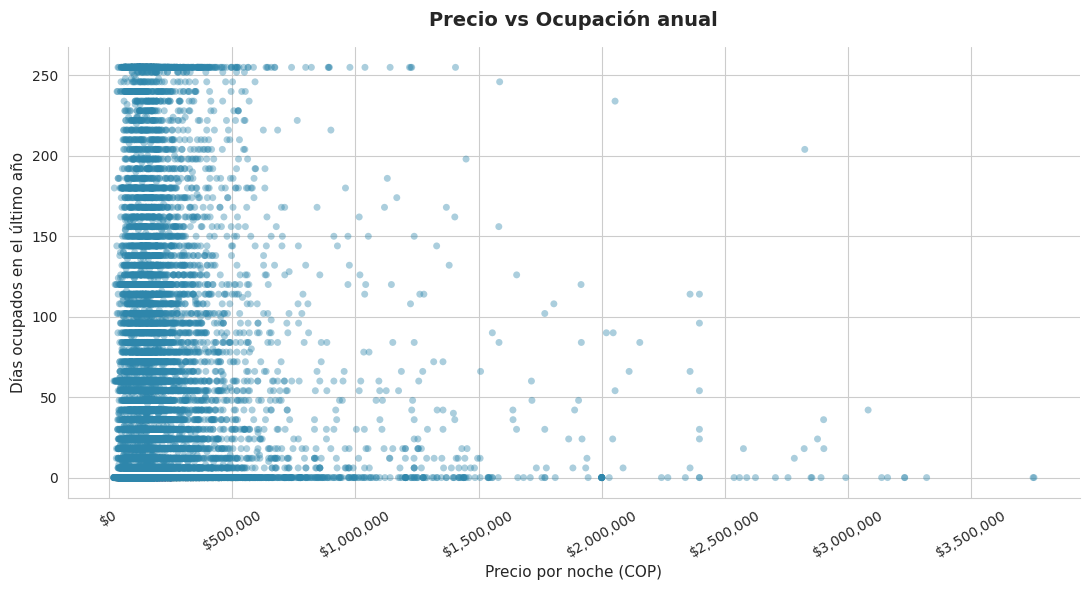

In [ ]:


plt.figure(figsize=(11, 6))
sns.scatterplot(data=df_analisis, x='price', y='estimated_occupancy_l365d',
                 alpha=0.4, color='#2E86AB', s=25, edgecolor='none')

plt.title('Precio vs Ocupación anual', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Precio por noche (COP)', fontsize=11)
plt.ylabel('Días ocupados en el último año', fontsize=11)

# Formatear el eje X en pesos, sin notación científica
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=30)

# Quitar bordes innecesarios para que se vea más limpia
sns.despine()
plt.tight_layout()
plt.show()

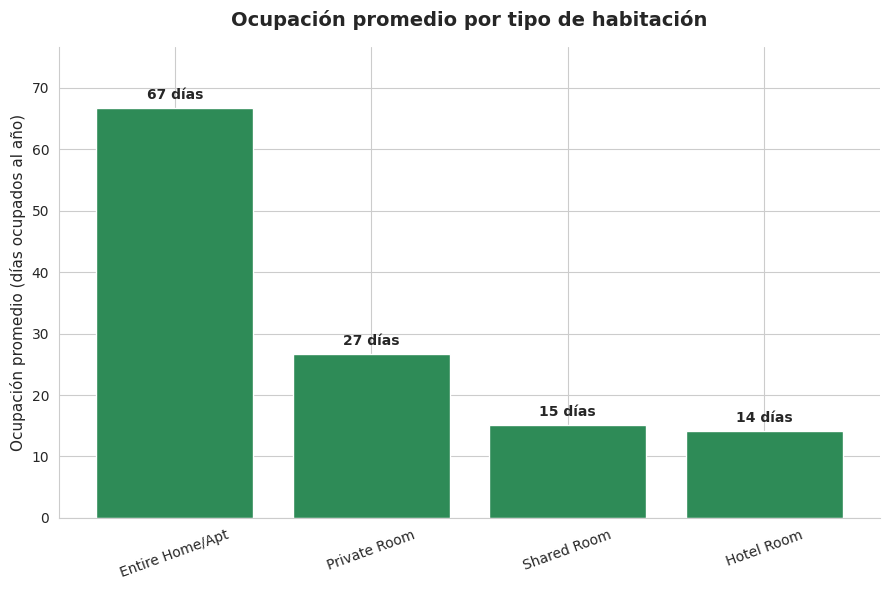

In [ ]:
ocupacion_por_tipo = df_analisis.groupby('room_type', observed=True)['estimated_occupancy_l365d'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
barras = ax.bar(ocupacion_por_tipo.index, ocupacion_por_tipo.values, color='seagreen')

plt.title('Ocupación promedio por tipo de habitación', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Ocupación promedio (días ocupados al año)', fontsize=11)
plt.xticks(rotation=20)

# Agregar el valor exacto encima de cada barra
for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, altura + 1, f'{altura:.0f} días',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Un poco de espacio extra arriba para que el texto no se corte
plt.ylim(0, ocupacion_por_tipo.max() * 1.15)

sns.despine()
plt.tight_layout()
plt.show()

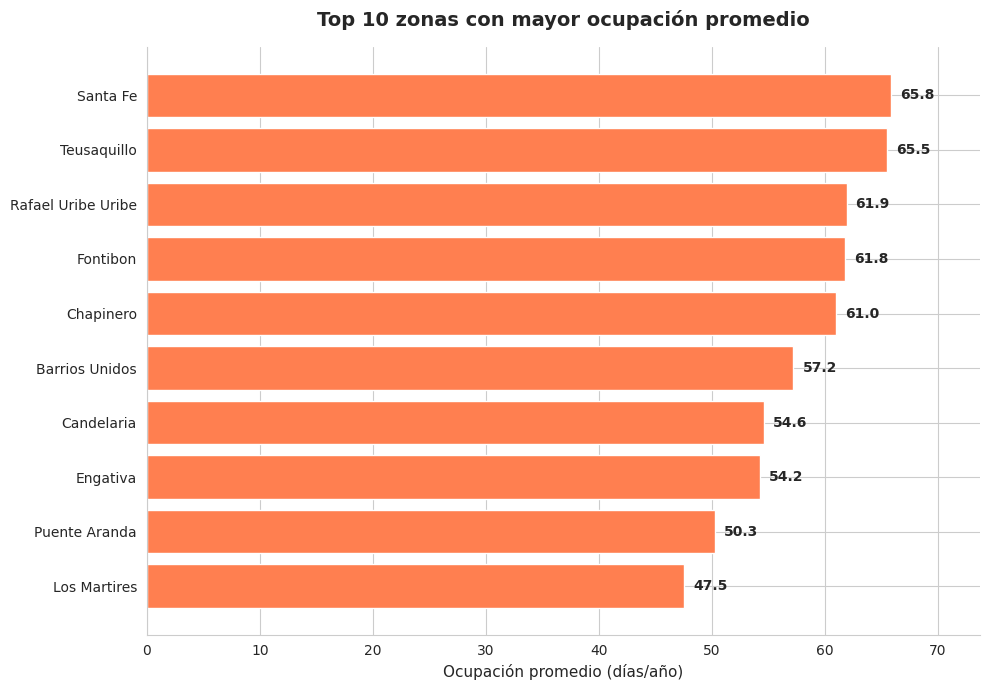

In [ ]:
resumen_zona = df_analisis.groupby('neighbourhood_cleansed').agg(
    ocupacion_prom=('estimated_occupancy_l365d', 'mean'),
    rating_prom=('review_scores_rating', 'mean'),
    num_listados=('id', 'count')
).sort_values('ocupacion_prom', ascending=False)

top10 = resumen_zona['ocupacion_prom'].head(10)

fig, ax = plt.subplots(figsize=(10, 7))
barras = ax.barh(top10.index, top10.values, color='coral')

plt.title('Top 10 zonas con mayor ocupación promedio', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ocupación promedio (días/año)', fontsize=11)
ax.invert_yaxis()

# Agregar el valor exacto al final de cada barra
for barra in barras:
    ancho = barra.get_width()
    ax.text(ancho + 0.8, barra.get_y() + barra.get_height()/2, f'{ancho:.1f}',
            ha='left', va='center', fontsize=10, fontweight='bold')

# Espacio extra a la derecha para que el texto no se corte
plt.xlim(0, top10.max() * 1.12)

sns.despine()
plt.tight_layout()
plt.show()

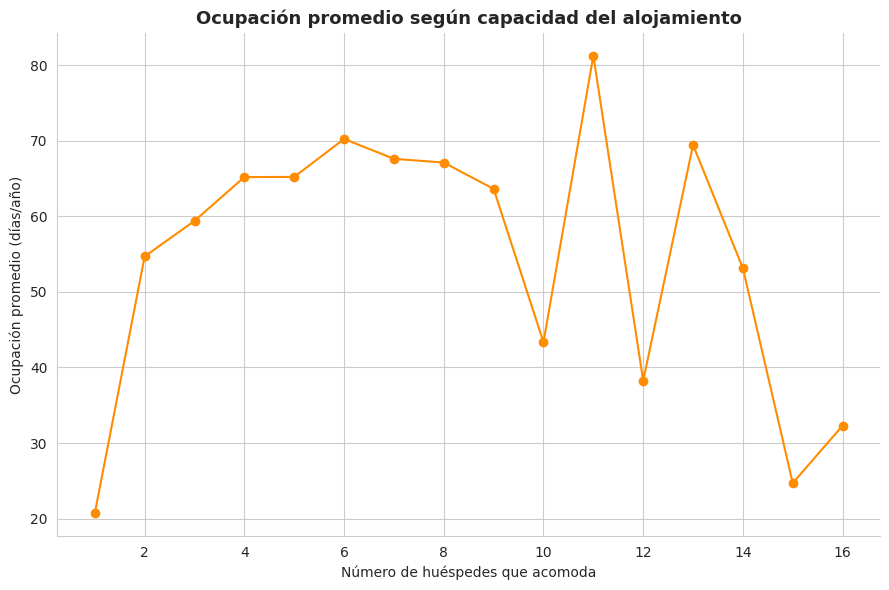

In [ ]:
ocupacion_por_capacidad = df_analisis.groupby('accommodates')['estimated_occupancy_l365d'].mean()

plt.figure(figsize=(9, 6))
ocupacion_por_capacidad.plot(kind='line', marker='o', color='darkorange')
plt.title('Ocupación promedio según capacidad del alojamiento', fontsize=13, fontweight='bold')
plt.xlabel('Número de huéspedes que acomoda')
plt.ylabel('Ocupación promedio (días/año)')
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px


fig = px.scatter_mapbox(
    df_analisis,
    lat='latitude',
    lon='longitude',
    color='estimated_occupancy_l365d',
    color_continuous_scale='Viridis',
    size_max=8,
    zoom=10,
    opacity=0.6,
    hover_name='neighbourhood_cleansed',
    labels={'estimated_occupancy_l365d': 'Ocupación (días/año)'},
    title='Distribución geográfica de listados por ocupación - Bogotá'
)

fig.update_layout(mapbox_style='open-street-map', height=700)
fig.show()

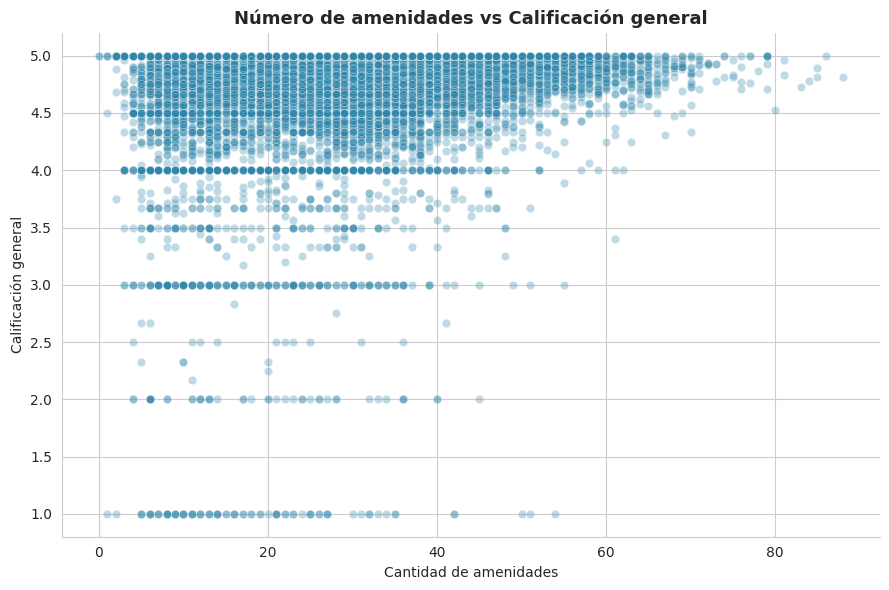

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_analisis, x='num_amenities', y='review_scores_rating', alpha=0.3, color='#2E86AB')
plt.title('Número de amenidades vs Calificación general', fontsize=13, fontweight='bold')
plt.xlabel('Cantidad de amenidades')
plt.ylabel('Calificación general')
sns.despine()
plt.tight_layout()
plt.show()

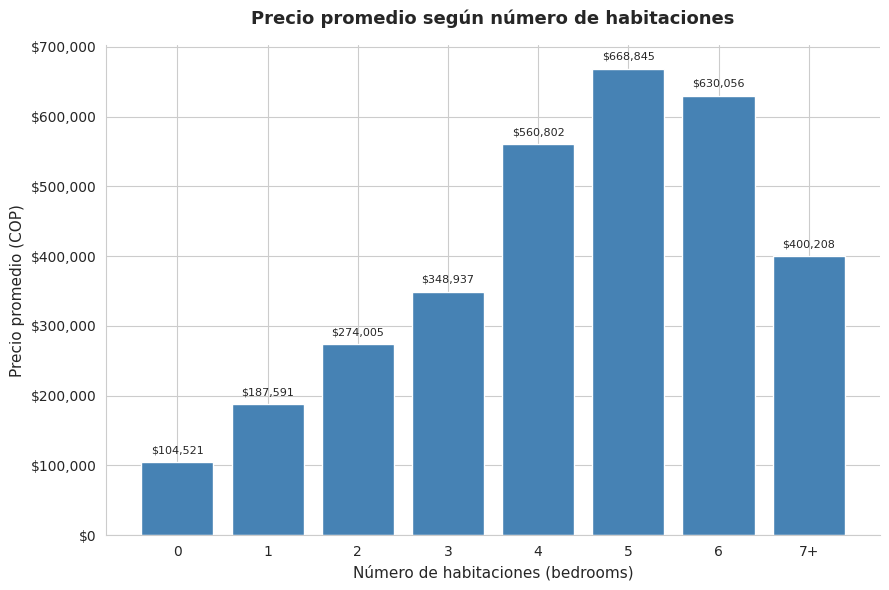

In [ ]:

# Agrupar solo hasta 6 habitaciones, el resto queda en "7+"
df_analisis['bedrooms_agrupado'] = df_analisis['bedrooms'].apply(
    lambda x: str(int(x)) if x <= 6 else '7+'
)

precio_por_habitaciones = df_analisis.groupby('bedrooms_agrupado')['price'].mean()

orden = ['0', '1', '2', '3', '4', '5', '6', '7+']
precio_por_habitaciones = precio_por_habitaciones.reindex(orden)

fig, ax = plt.subplots(figsize=(9, 6))
barras = ax.bar(precio_por_habitaciones.index, precio_por_habitaciones.values, color='steelblue')

plt.title('Precio promedio según número de habitaciones', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Número de habitaciones (bedrooms)', fontsize=11)
plt.ylabel('Precio promedio (COP)', fontsize=11)
plt.xticks(rotation=0)

# Formato del eje y
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))


for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, altura + 10000, f'${altura:,.0f}',
            ha='center', va='bottom', fontsize=8, rotation=0)

sns.despine()
plt.tight_layout()
plt.show()

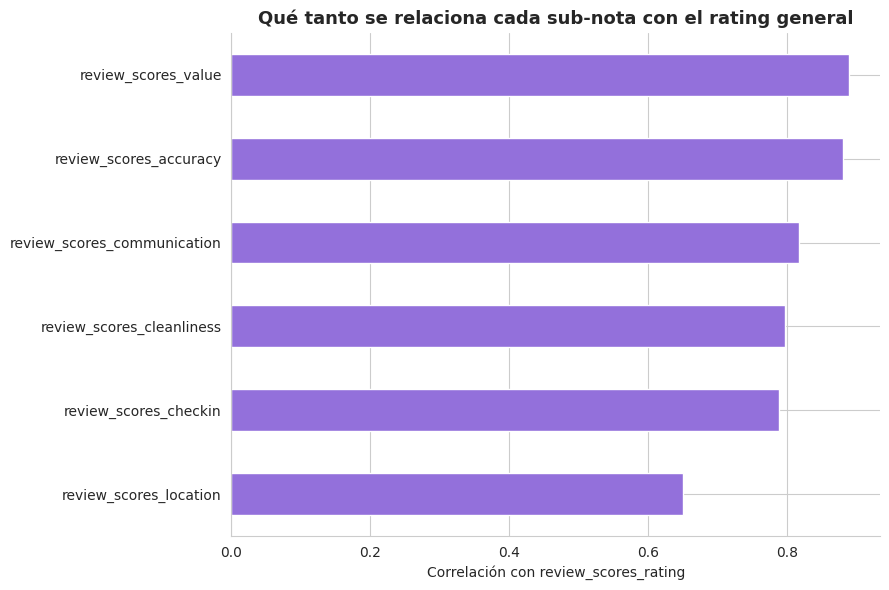

In [ ]:
cols_calidad = ['review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
                 'review_scores_communication', 'review_scores_location', 'review_scores_value']

correlaciones = df_analisis[cols_calidad + ['review_scores_rating']].corr()['review_scores_rating'].drop('review_scores_rating').sort_values(ascending=False)

plt.figure(figsize=(9, 6))
correlaciones.plot(kind='barh', color='mediumpurple')
plt.title('Qué tanto se relaciona cada sub-nota con el rating general', fontsize=13, fontweight='bold')
plt.xlabel('Correlación con review_scores_rating')
plt.gca().invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

# 6. Interpretación de los resultados exploratorios

## 6.1 Precio y ocupación

El diagrama de dispersión permite observar la relación entre el precio por noche y los días de ocupación estimada durante los últimos 365 días. El resultado reportado por el proyecto muestra una correlación de Pearson de aproximadamente **r = -0,027**, un valor muy cercano a cero. Por tanto, dentro de este conjunto de datos no se observa una relación lineal fuerte entre precio y ocupación.

Esto no significa que el precio no tenga ninguna importancia comercial; significa que el precio por sí solo no explica linealmente la variación de la ocupación. Es posible que intervengan simultáneamente la ubicación, el tipo de alojamiento, la capacidad, la disponibilidad y otras características.

## 6.2 Tipo de alojamiento

La comparación por `room_type` muestra diferencias en la ocupación promedio. En los resultados del proyecto, los alojamientos completos presentan el promedio más alto, alrededor de 67 días ocupados al año, mientras que las habitaciones privadas y otros tipos presentan promedios menores.

El tipo de alojamiento aparece, por tanto, como una variable más informativa para describir diferencias de ocupación que el precio considerado aisladamente.

## 6.3 Ubicación

El agrupamiento por `neighbourhood_cleansed` permite identificar las zonas con mayores promedios de ocupación. En los resultados del proyecto destacan **Santa Fe (65,8 días)** y **Teusaquillo (65,5 días)**.

Estos valores son promedios del conjunto analizado y no significan que todos los alojamientos de esas localidades tengan ese nivel de ocupación.

## 6.4 Capacidad

La gráfica de ocupación promedio según `accommodates` permite observar cómo cambia la ocupación promedio cuando aumenta la capacidad del alojamiento. Esta visualización sirve para detectar tendencias y posibles puntos de cambio, aunque la relación no debe interpretarse como causalidad.

## 6.5 Distribución geográfica

El mapa utiliza latitud y longitud para visualizar la distribución de los listados y colorearlos según la ocupación estimada. Inside Airbnb advierte que las ubicaciones están anonimizadas, por lo que el mapa debe interpretarse como una representación aproximada de la distribución geográfica y no como la dirección exacta de cada propiedad.

## 6.6 Amenidades y calidad

La gráfica de `num_amenities` frente a `review_scores_rating` explora si una mayor cantidad de servicios está acompañada por una mayor calificación general. La visualización permite detectar patrones, pero por sí sola no demuestra causalidad.

## 6.7 Habitaciones y precio

La gráfica final del EDA compara el precio promedio según el número de habitaciones, agrupando los alojamientos con más de seis habitaciones como `7+`. Esto permite analizar cómo cambia el precio promedio con una de las principales características físicas del alojamiento.


# 7. Análisis estadístico

El análisis estadístico del proyecto es principalmente descriptivo y correlacional. La estadística descriptiva se obtiene con `DataFrame.describe()` y permite revisar medidas como media, mediana, desviación estándar, mínimo y máximo. La documentación oficial de pandas describe `describe()` como un resumen de las estadísticas descriptivas de las columnas del DataFrame. [Pandas — DataFrame.describe](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)

La correlación se utiliza para estudiar asociaciones lineales entre variables numéricas. En el código se utiliza `corr()` para obtener la matriz de correlaciones y posteriormente se selecciona la relación con `review_scores_rating`. [Pandas — DataFrame.corr](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)

## Resultados descriptivos principales

| Variable | Resultado observado |
|---|---:|
| Ocupación estimada | Media: **55,5 días/año** mediana: **18 días** |
| Precio | Media: **$208.574**;  mediana: **$160.976** |
| Calificación general | Media: **4,704**; mediana: **4,83** |
| Amenidades | Media: **26,43**; mediana: **26** |
| Habitaciones | Media: **1,31**; mediana: **1** |

La diferencia entre media y mediana de la ocupación muestra que la distribución no es simétrica: una parte de los alojamientos presenta niveles de ocupación considerablemente superiores al valor central.

## Correlación precio–ocupación

El proyecto reporta **r = -0,027** entre precio y ocupación. Al ser un valor muy cercano a cero, la asociación lineal es muy débil.

## Correlación de subcalificaciones

Se calculan las correlaciones entre `review_scores_rating` y las variables de calidad: exactitud, limpieza, check-in, comunicación, ubicación y valor. El gráfico permite comparar cuáles de estas dimensiones tienen una asociación más alta con el rating general.

> Una correlación no implica causalidad. En este proyecto se utiliza como herramienta exploratoria para identificar relaciones que podrían estudiarse con mayor profundidad en una etapa de modelado.


# 8. Hallazgos e insights

### Hallazgo 1 — El precio no explica por sí solo la ocupación

La correlación precio–ocupación de **-0,027** indica que no existe una relación lineal fuerte entre ambas variables. Esto sugiere que analizar solamente el precio sería insuficiente para explicar el desempeño de un alojamiento.

### Hallazgo 2 — El tipo de alojamiento muestra diferencias de ocupación

Los alojamientos completos presentan el promedio de ocupación más alto en la comparación realizada. El tipo de alojamiento parece ser una dimensión relevante para segmentar el mercado.

### Hallazgo 3 — La ubicación presenta diferencias

Santa Fe y Teusaquillo aparecen entre las localidades con mayor ocupación promedio, con **65,8 y 65,5 días**, respectivamente. Estos resultados permiten identificar zonas que merecen una revisión más detallada.

### Hallazgo 4 — La calidad puede estudiarse por componentes

La calificación general no debe verse como una variable aislada. Las subcalificaciones de exactitud, limpieza, check-in, comunicación, ubicación y valor permiten descomponer la experiencia del huésped y observar qué dimensiones están más relacionadas con el rating.

### Hallazgo 5 — La limpieza cambia la lectura del precio

El tratamiento de los valores extremos es importante. La diferencia entre el máximo original y el máximo después de la limpieza demuestra que algunos registros podían distorsionar fuertemente la escala de los gráficos.


**Crudo VS Limpio**

## Comparación final: crudo vs. limpio

La siguiente celda es **código original del proyecto**. Su objetivo es mostrar visualmente cómo cambia la distribución del precio después de aplicar la limpieza y el filtro de valores extremos.

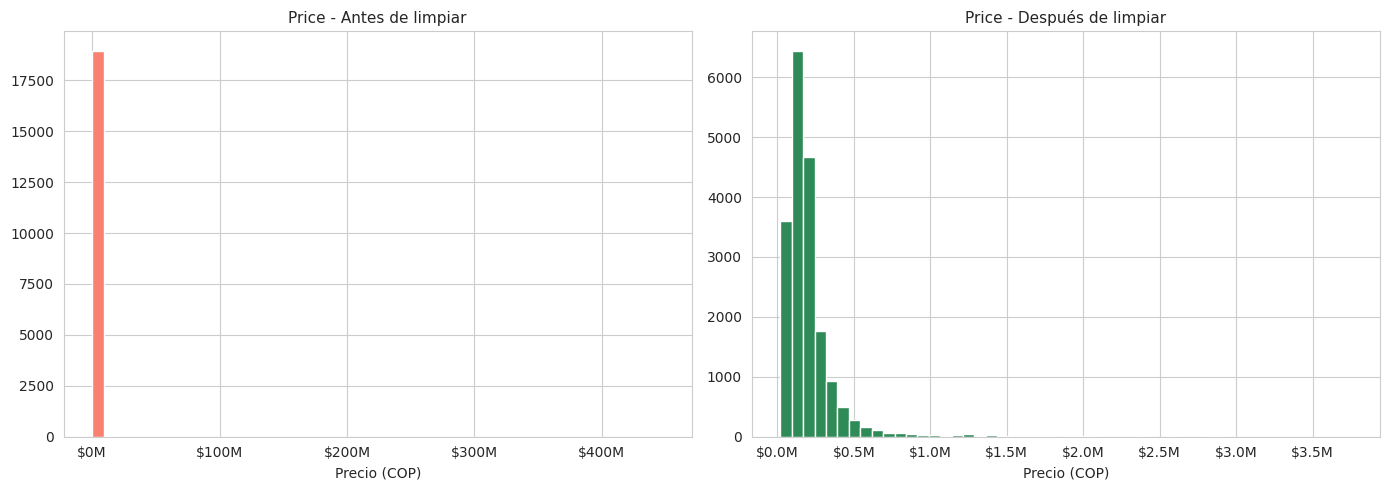

Precio máximo ANTES de limpiar: $448,176,567
Precio máximo DESPUÉS de limpiar: $3,754,276


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_crudo = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

axes[0].hist(price_crudo.dropna(), bins=50, color='salmon')
axes[0].set_title('Price - Antes de limpiar', fontsize=11)
axes[0].set_xlabel('Precio (COP)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000000:.0f}M'))

# Derecha: limpio
axes[1].hist(df_limpio['price'], bins=50, color='seagreen')
axes[1].set_title('Price - Después de limpiar', fontsize=11)
axes[1].set_xlabel('Precio (COP)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000000:.1f}M'))

plt.tight_layout()
plt.show()

print(f"Precio máximo ANTES de limpiar: ${price_crudo.max():,.0f}")
print(f"Precio máximo DESPUÉS de limpiar: ${df_limpio['price'].max():,.0f}")

# 9. Selección, aplicación y evaluación del modelo

Se construyen dos modelos, uno para cada variable objetivo del proyecto, siguiendo la etapa de modelado de la metodología CRISP-DM [IBM — CRISP-DM](https://public.dhe.ibm.com/software/analytics/spss/documentation/modeler/14.2/es/CRISP-DM.pdf):

- **Modelo 1 — Regresión lineal múltiple:** predice `review_scores_rating` (variable numérica continua).
- **Modelo 2 — Clasificación:** predice el nivel de ocupación (baja/media/alta), derivado de `estimated_occupancy_l365d`.

Se usan dos modelos distintos porque cada variable objetivo tiene una naturaleza diferente: el rating es una escala continua con relaciones aproximadamente lineales con sus predictores (visto en la Sección 7), mientras que la ocupación tiene una distribución muy asimétrica (media 55,5 días, mediana 18 días), lo que hace más robusto tratarla como categorías de desempeño en vez de un valor exacto.

Implementación con `scikit-learn`. [Scikit-learn — User Guide](https://scikit-learn.org/stable/user_guide.html)

## 9.1 Selección de variables predictoras

Antes de entrenar cualquier modelo, se excluyen del conjunto de predictores:
- Identificadores sin valor predictivo: `id`, `name`, `host_id`, `host_name`.
- Las variables objetivo de cada modelo (no pueden predecirse a sí mismas).
- Las sub-calificaciones (`review_scores_accuracy`, `cleanliness`, `checkin`, `communication`, `location`, `value`) como predictoras del Modelo 1: estas conforman aritméticamente el rating general, por lo que incluirlas generaría **fuga de datos (data leakage)** — el modelo aprendería una relación artificial y no un patrón real y accionable.
- `estimated_revenue_l365d` como predictora del Modelo 2: se calcula a partir de precio × ocupación, por lo que ya contiene información directa sobre la variable objetivo.

In [ ]:
# Copia de trabajo exclusiva para el modelado
df_modelo = df_limpio.copy()

# Agrupar property_type: hay demasiadas categorías únicas, muchas con pocos casos
top_property_types = df_modelo['property_type'].value_counts().nlargest(6).index
df_modelo['property_type_agrupado'] = df_modelo['property_type'].apply(
    lambda x: x if x in top_property_types else 'Other'
)

print(df_modelo['property_type_agrupado'].value_counts())

property_type_agrupado
Entire Rental Unit             10294
Other                           2792
Private Room In Rental Unit     1516
Private Room In Home            1364
Entire Loft                     1159
Entire Serviced Apartment       1019
Room In Hotel                    805
Name: count, dtype: int64


## 9.2 Modelo 1: Regresión lineal múltiple

**Variable objetivo:** `review_scores_rating`
**Predictoras:** precio, ubicación, características del alojamiento y variables del host — excluyendo las sub-calificaciones por fuga de datos.

Se divide el dataset en entrenamiento (80%) y prueba (20%) con `train_test_split`, y se codifican las variables categóricas con `pd.get_dummies` (codificación one-hot). [Scikit-learn — train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Eliminar filas sin rating (no se puede entrenar ni evaluar sin la variable objetivo)
df_reg = df_modelo.dropna(subset=['review_scores_rating']).copy()

# Variables predictoras seleccionadas (sin sub-calificaciones, sin IDs, sin la otra variable objetivo)
predictoras_reg = [
    'price', 'minimum_nights', 'maximum_nights', 'number_of_reviews_ltm', 'reviews_per_month',
    'neighbourhood_cleansed', 'property_type_agrupado', 'room_type',
    'accommodates', 'num_amenities', 'bedrooms', 'beds', 'bathrooms', 'availability_365',
    'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
    'hosts_time_as_user_years', 'hosts_time_as_host_years'
]

X = df_reg[predictoras_reg]
y = df_reg['review_scores_rating']

# Codificar variables categóricas (texto) en columnas numéricas 0/1
X = pd.get_dummies(X, columns=['neighbourhood_cleansed', 'property_type_agrupado', 'room_type'], drop_first=True)

# Rellenar nulos restantes en predictoras numéricas con la mediana, para no perder filas
X = X.fillna(X.median(numeric_only=True))

print(f"Filas: {X.shape[0]}, Predictoras (tras codificar): {X.shape[1]}")

Filas: 14826, Predictoras (tras codificar): 44


In [ ]:
# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
modelo_reg = LinearRegression()
modelo_reg.fit(X_train, y_train)

# Predecir sobre el conjunto de prueba (datos que el modelo nunca vio)
y_pred = modelo_reg.predict(X_test)



In [ ]:
coeficientes = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': modelo_reg.coef_
}).sort_values('coeficiente', key=abs, ascending=False)

print(coeficientes.head(15))

                                             variable  coeficiente
30                     neighbourhood_cleansed_Sumapaz     0.474018
34                        neighbourhood_cleansed_Usme     0.291828
17                        neighbourhood_cleansed_Bosa    -0.254115
32                  neighbourhood_cleansed_Tunjuelito     0.239128
40               property_type_agrupado_Room In Hotel    -0.208325
11                                  host_is_superhost     0.206824
27               neighbourhood_cleansed_San Cristobal     0.172132
20              neighbourhood_cleansed_Ciudad Bolivar    -0.134511
41                               room_type_Hotel Room    -0.103122
21                    neighbourhood_cleansed_Engativa     0.092746
26          neighbourhood_cleansed_Rafael Uribe Uribe     0.088429
39  property_type_agrupado_Private Room In Rental ...     0.085529
24                neighbourhood_cleansed_Los Martires     0.077243
25               neighbourhood_cleansed_Puente Aranda     0.07

### Métricas de evaluación — Regresión

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho por el modelo, para $n$ observaciones:

**MAE (Error Absoluto Medio):**
$$MAE = \frac{1}{n}\sum_{i=1}^{n} |\hat{y}_i - y_i|$$
Promedio de qué tanto se equivoca el modelo, sin importar si se equivoca por arriba o por abajo (por eso el valor absoluto).

**MSE (Error Cuadrático Medio):**
$$MSE = \frac{1}{n}\sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$
Similar al MAE, pero eleva cada error al cuadrado — esto penaliza mucho más los errores grandes que los pequeños.

**RMSE (Raíz del Error Cuadrático Medio):**
$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (\hat{y}_i - y_i)^2}$$
Es la raíz cuadrada del MSE, para devolver el error a las **mismas unidades** que la variable original (en nuestro caso, puntos de rating), lo que lo hace más fácil de interpretar que el MSE.

**R² (Coeficiente de determinación):**
Mide qué proporción de la variabilidad de la variable objetivo logra explicar el modelo. Va de 0 a 1 — mientras más cerca de 1, mejor explica el modelo los datos.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MAE  : 0.242
MSE  : 0.175
RMSE : 0.419
R²   : 0.111


#### Interpretación de resultados

El modelo obtiene un **R² de 0.111**, lo que indica que las variables seleccionadas explican aproximadamente el **11% de la variabilidad** en la calificación general. El **MAE de 0.242** significa que, en promedio, el modelo se equivoca en 0.24 puntos sobre una escala de 5 al predecir el rating.

Este R² relativamente bajo es un resultado esperable y honesto: el rating de un huésped depende en gran parte de percepciones subjetivas (experiencia personal, expectativas previas) que no están capturadas en variables estructurales como precio o ubicación. El hallazgo de valor no es "predecir el rating con precisión", sino identificar qué variables estructurales sí tienen relación con él.

De los coeficientes, destaca que `host_is_superhost` tiene un efecto positivo de +0.207 puntos — confirma cuantitativamente el patrón que ya se había observado en el EDA (Sección 6). También se observan efectos importantes por localidad (`neighbourhood_cleansed`), sugiriendo que la zona de la ciudad está asociada con diferencias sistemáticas en la calificación, más allá de las características del alojamiento en sí.

## 9.3 Modelo 2: Clasificación del nivel de ocupación

Se transforma `estimated_occupancy_l365d` en una variable categórica de 3 niveles (Baja/Media/Alta), usando terciles (cada grupo contiene aproximadamente un tercio de los listados). Se entrena un modelo de regresión logística multinomial. [Scikit-learn — LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

**Nota sobre la construcción de categorías:** se utilizan límites definidos manualmente (`pd.cut`) en vez de terciles automáticos (`pd.qcut`), porque el 36% de los listados presentan exactamente 0 días de ocupación estimada — esto impide dividir el dataset en tres grupos de igual tamaño mediante percentiles. Los listados sin ocupación se clasifican como "Baja"; el resto se divide en "Media" y "Alta" según la mediana de los listados que sí tuvieron actividad (60 días).

In [ ]:
df_clas = df_modelo.copy()

# Los listados con 0 días de ocupación son un grupo claramente distinto (36% del dataset)
# Para el resto, dividimos por la mediana de los que SÍ tuvieron ocupación
no_cero = df_clas.loc[df_clas['estimated_occupancy_l365d'] > 0, 'estimated_occupancy_l365d']
mediana_no_cero = no_cero.median()  # 60.0

bins = [-1, 0, mediana_no_cero, df_clas['estimated_occupancy_l365d'].max()]
df_clas['nivel_ocupacion'] = pd.cut(
    df_clas['estimated_occupancy_l365d'],
    bins=bins,
    labels=['Baja', 'Media', 'Alta']
)

print(df_clas['nivel_ocupacion'].value_counts())

nivel_ocupacion
Baja     6827
Media    6429
Alta     5693
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

predictoras_clas = [
    'price', 'minimum_nights', 'maximum_nights', 'number_of_reviews_ltm', 'reviews_per_month',
    'neighbourhood_cleansed', 'property_type_agrupado', 'room_type',
    'accommodates', 'num_amenities', 'bedrooms', 'beds', 'bathrooms',
    'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
    'review_scores_rating'
]

df_clas_final = df_clas.dropna(subset=['nivel_ocupacion']).copy()

X_c = df_clas_final[predictoras_clas]
y_c = df_clas_final['nivel_ocupacion']

X_c = pd.get_dummies(X_c, columns=['neighbourhood_cleansed', 'property_type_agrupado', 'room_type'], drop_first=True)
X_c = X_c.fillna(X_c.median(numeric_only=True))

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

modelo_clas = LogisticRegression(max_iter=1000)
modelo_clas.fit(X_train_c, y_train_c)

y_pred_c = modelo_clas.predict(X_test_c)

print(f"Exactitud (accuracy): {accuracy_score(y_test_c, y_pred_c):.3f}")
print()
print(classification_report(y_test_c, y_pred_c))

Exactitud (accuracy): 0.824

              precision    recall  f1-score   support

        Alta       0.84      0.91      0.87      1139
        Baja       0.85      0.80      0.83      1365
       Media       0.78      0.77      0.78      1286

    accuracy                           0.82      3790
   macro avg       0.82      0.83      0.83      3790
weighted avg       0.82      0.82      0.82      3790



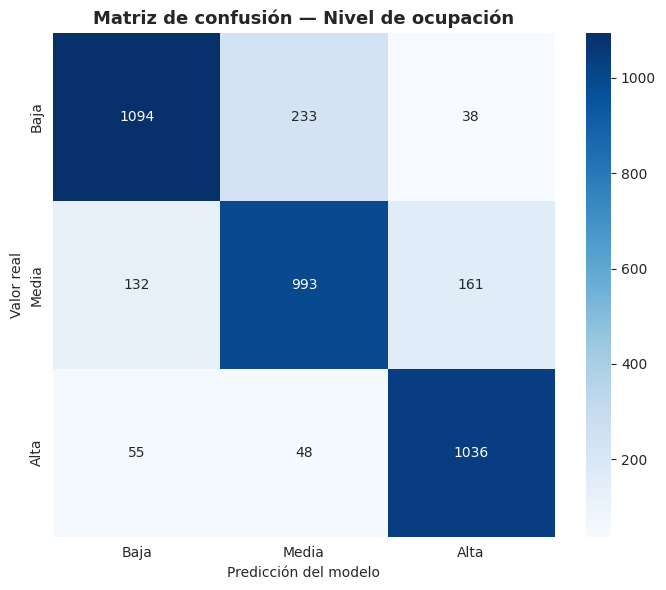

In [ ]:
matriz = confusion_matrix(y_test_c, y_pred_c, labels=['Baja', 'Media', 'Alta'])

plt.figure(figsize=(7, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baja', 'Media', 'Alta'], yticklabels=['Baja', 'Media', 'Alta'])
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.title('Matriz de confusión — Nivel de ocupación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Métricas de evaluación — Clasificación

**Matriz de confusión:** compara lo que el modelo predijo contra lo que realmente ocurrió, organizando los resultados en Verdaderos Positivos (TP), Falsos Negativos (FN), Falsos Positivos (FP) y Verdaderos Negativos (TN).

**Exactitud (Accuracy):**
$$Accuracy = \frac{TP + TN}{TP + FP + FN + TN}$$
Porcentaje total de predicciones correctas, sobre el total de casos.

**Precisión (Precision):**
$$Precision = \frac{TP}{TP + FP}$$
De todo lo que el modelo predijo como positivo (ej. "Alta ocupación"), qué porcentaje realmente lo era.

**Recall (Sensibilidad):**
$$Recall = \frac{TP}{TP + FN}$$
De todos los casos que realmente eran positivos, qué porcentaje logró identificar el modelo.

**F1-Score:**
$$F1 = \frac{2 \times Precision \times Recall}{Precision + Recall}$$
Combina precisión y recall en un solo número — útil cuando quieres balancear ambas métricas en vez de priorizar una sobre la otra.

**Nota:** como este es un problema de clasificación de 3 clases (Baja/Media/Alta) y no binario, `scikit-learn` calcula precisión, recall y F1 **por cada clase individualmente** (tratando esa clase como "positivo" y las otras dos como "negativo"), y luego promedia los resultados. Esto es lo que reporta `classification_report()`.

#### Interpretación de resultados

El modelo alcanza una **exactitud (accuracy) del 82.4%**. Por categoría:

- **Baja**: precisión 0.85, recall 0.80 — el modelo identifica correctamente el 80% de los listados sin ocupación real, y cuando predice "Baja", acierta el 85% de las veces.
- **Media**: precisión 0.78, recall 0.77 — la categoría más difícil de distinguir, por ser la intermedia entre las otras dos.
- **Alta**: precisión 0.84, recall 0.91 — la categoría mejor identificada por el modelo.

En la matriz de confusión, los errores se concentran entre categorías **adyacentes** (Baja↔Media: 233+132=365 casos; Media↔Alta: 161+48=209 casos), mientras que la confusión entre los extremos es mínima (Baja↔Alta: solo 38+55=93 casos). Esto indica que el modelo captura una progresión lógica en el nivel de ocupación, en vez de cometer errores aleatorios.

## 9.4 Evaluación e interpretación conjunta

Los dos modelos abordan las dos mitades de la pregunta central del proyecto, con resultados de calidad distinta:

- El **Modelo 1 (regresión)**, con **R² = 0.111**, muestra que la calificación general depende solo parcialmente de variables estructurales — la mayor parte de su variabilidad responde a factores subjetivos no capturados en el dataset (experiencia personal del huésped, expectativas previas). Aun así, identifica relaciones interpretables: `host_is_superhost` tiene un efecto positivo de +0.21 puntos sobre el rating, y varias localidades muestran efectos sistemáticos propios.

- El **Modelo 2 (clasificación)**, con **82.4% de exactitud**, demuestra que sí existen patrones claros y predecibles que distinguen listados de alta, media y baja ocupación. El modelo identifica mejor la categoría "Alta" (recall 0.91) y tiene más dificultad con "Media" (la categoría intermedia, conceptualmente más ambigua). Los errores se concentran entre categorías adyacentes, y son mínimos entre los extremos (Baja↔Alta), lo que indica que el modelo captura una progresión lógica en vez de errores aleatorios.

**Conclusión metodológica:** la ocupación es considerablemente más predecible que la calificación a partir de las variables disponibles (82.4% de exactitud vs. 11.1% de varianza explicada). Esto sugiere que el desempeño comercial de un Airbnb en Bogotá depende más de decisiones controlables por el anfitrión (precio, ubicación, tipo de propiedad, gestión) que la satisfacción subjetiva del huésped, la cual depende de factores más difíciles de capturar en datos estructurados.

**Limitaciones:** ambos modelos son lineales por diseño (regresión lineal y regresión logística), priorizando la interpretabilidad de los coeficientes sobre el poder predictivo máximo. Un R² moderado no invalida el análisis del Modelo 1: sigue siendo evidencia válida de qué variables se asocian con mejor calificación, que es el objetivo del proyecto — no construir un sistema de predicción de producción.

# 10. Conclusiones

1. El proyecto parte de un conjunto de **19.187 registros y 90 variables** y, después de la limpieza y selección, trabaja con **18.949 registros y 34 variables**.
2. La preparación de los datos fue necesaria para corregir tipos, valores extremos, codificación de texto, datos faltantes y variables que no eran relevantes para las preguntas del proyecto.
3. La ocupación estimada presenta una media de **55,5 días al año** y una mediana de **18 días**, mostrando una distribución con diferencias importantes entre alojamientos.
4. El precio presenta una relación lineal muy débil con la ocupación (**r = -0,027**), por lo que no puede considerarse un predictor suficiente por sí solo.
5. El tipo de alojamiento y la ubicación muestran diferencias más visibles en los promedios de ocupación.
6. La calificación general puede analizarse a través de sus componentes de exactitud, limpieza, check-in, comunicación, ubicación y valor.
7. Las visualizaciones permiten transformar las variables del dataset en evidencia comprensible y facilitan la comunicación de los patrones encontrados.
8. Para completar todos los puntos de la rúbrica de la asignatura todavía sería necesario incorporar un modelo predictivo, justificarlo, entrenarlo y evaluar su desempeño.


# 11. Recomendaciones

- Mantener la separación entre el dataset original (`df`) y el dataset limpio (`df_limpio`).
- Conservar la documentación de cada transformación para que las decisiones sean reproducibles.
- Antes de construir un modelo, revisar posibles variables que puedan producir fuga de información.
- Incorporar una etapa de modelado predictivo si la entrega final exige cumplir todos los puntos de la rúbrica.
- Comparar más de un modelo y reportar métricas de evaluación apropiadas.
- Interpretar los resultados del modelo junto con los hallazgos del EDA, evitando presentar una métrica como si fuera una explicación causal.
- Mantener las visualizaciones enfocadas en las preguntas de investigación y no solamente en mostrar gráficos.
- Para GitHub, incluir este cuaderno, el informe/presentación y un README con la fuente de datos, estructura del repositorio y pasos de ejecución.


# 12. Referencias

### Fuente de datos

1. **Inside Airbnb.** *Get the Data*. Datos públicos de listados de Airbnb. https://insideairbnb.com/es/get-the-data/?hl=es-AR
2. **Inside Airbnb.** *Data Assumptions*. Metodología, supuestos y limitaciones de los datos. https://insideairbnb.com/data-assumptions/

### Referencias metodológicas y técnicas

3. **IBM.** *CRISP-DM 1.0: Step-by-step data mining guide*. Marco de referencia para organizar proyectos de minería de datos. https://public.dhe.ibm.com/software/analytics/spss/documentation/modeler/14.2/es/CRISP-DM.pdf
4. **pandas documentation.** *DataFrame.describe*. Documentación utilizada como referencia para la estadística descriptiva empleada en el notebook. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html
5. **pandas documentation.** *DataFrame.corr*. Documentación de la función de correlación utilizada en el análisis. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html
6. **Seaborn documentation.** Biblioteca utilizada para varias visualizaciones estadísticas del proyecto. https://seaborn.pydata.org/
7. **Plotly documentation.** Referencia para las visualizaciones geográficas interactivas utilizadas en el notebook. https://plotly.com/python/scatter-plots-on-maps/

### Materiales del proyecto

8. **Google Colab del grupo.** *AIRBNB_BOGOTA*. Código original del proyecto.
9. **Presentación del grupo.** *Data Experience — De datos a decisiones: el mercado Airbnb en Bogotá*.

> Las conclusiones y cifras específicas del proyecto se derivan del dataset y del análisis realizado por el grupo. Las referencias externas se utilizan para documentar la fuente de datos, sus supuestos y las herramientas/metodologías empleadas.


# 13. Cierre del proyecto

Este cuaderno reúne el **código original y el informe en un mismo archivo**. La ventaja de trabajar de esta forma es que cada etapa queda acompañada por una explicación: primero se plantea la pregunta, después se documenta la fuente y la preparación de los datos, luego se ejecuta el análisis y finalmente se interpretan los resultados.

### Verificación de integridad

- El código original se conserva sin modificaciones.
- Las celdas nuevas son únicamente de tipo Markdown.
- Las visualizaciones y transformaciones originales permanecen en el mismo orden.
- La etapa de modelado se declara como pendiente porque no existe en el Colab original.
- Las referencias se concentran al final y también se citan en las secciones donde aportan contexto metodológico.

**Este archivo es la copia recomendada para subir a Google Colab y posteriormente descargar/subir al repositorio de GitHub.**
